# Chapter 2 bounds demo
Numerical sanity checks for FMP bounds on small toy systems.

## 1) Environment/bootstrap
This cell configures imports so the notebook works whether or not `mpmgame` is pre-installed in the kernel.

**Expected outcome:** prints the import path for `mpmgame`.

In [1]:
from pathlib import Path
import sys
cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'mpmgame').exists():
        sys.path.insert(0, str(src_dir))
        break
import numpy as np
import pandas as pd
import mpmgame as mpm
print('using', mpm.__file__)


using C:\Users\perry\Documents\VSCode\masked-perturbation-model\src\mpmgame\__init__.py


## 2) Family A: vary realization strength `Q = λQ0`
This block builds a fixed base system (`G`, `alpha`) and sweeps `λ` to vary the realization matrix while keeping contracts/interconnection fixed.

**What it demonstrates:** how measured vulnerability and bound overlays move as `Q` strength changes.

**Expected behavior:** lower/upper curves act as directional checks under their assumptions; measured curve is the primary empirical quantity.

In [2]:
G = np.diag([0.8, 0.6, 0.5])
alpha0 = np.array([[0, 0.3, 0], [0.2, 0, 0.1], [0, 0.25, 0]])
system = mpm.build_contract_system(G, alpha0, label='base_static')
Q0 = np.array([[0, 0.4, -0.2], [0.1, 0, 0.3], [-0.1, 0.2, 0]])
lambdas = np.linspace(0, 0.8, 9)
fam_q = mpm.family_vary_q(system, Q0, lambdas, access_model='w2', threat_model='single_link')
fam_q.data.head()


,lambda,q_norm_2,measured,lower_single,lower_full,upper_full
0,0.0,0.000000,1.037667,0.192450,0.787029,1.250081
1,0.1,0.050693,1.044848,0.183165,0.787029,1.250081
2,0.2,0.101387,1.053914,0.174734,0.787029,1.250081
3,0.3,0.152080,1.064845,0.167046,0.787029,1.250081
4,0.4,0.202774,1.077643,0.160005,0.787029,1.250081


## 3) Plot Family A curves
This figure shows measured vulnerability versus `λ` for the single-link threat model, with available bound overlays.

**How to read:**
- solid line: measured vulnerability,
- dashed lines: theorem-inspired bound helpers (assumption dependent).

A loose or nearly constant bound is still valid as a conservative reference in this numerical setting.

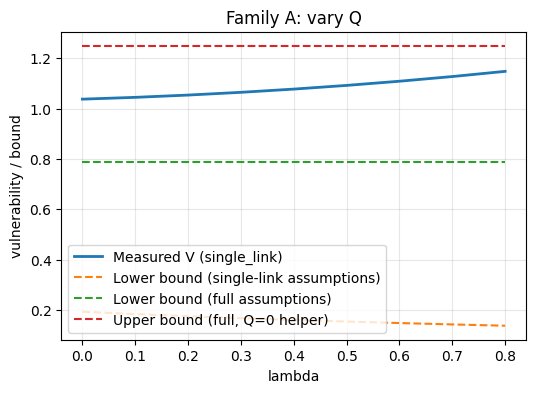

In [3]:
_ = mpm.plot_vulnerability_vs_parameter(fam_q.data, x='lambda', title='Family A: vary Q', threat_model='single_link')


## 4) Family B: vary interconnection strength `alpha = ρ alpha0`
This block sweeps `ρ` while keeping contracts and `Q` fixed, then plots full-threat measured vulnerability with a lower-bound overlay.

**What it demonstrates:** how coupling/interconnection gain affects vulnerability and the `||G alpha||`-linked lower bound trend.

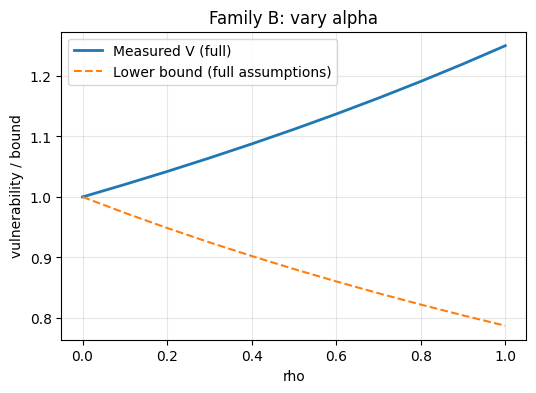

In [4]:
rhos = np.linspace(0, 1.0, 11)
fam_a = mpm.family_vary_alpha(G, alpha0, rhos, Q=np.zeros_like(G), access_model='w2', threat_model='full')
_ = mpm.plot_vulnerability_vs_parameter(fam_a.data, x='rho', title='Family B: vary alpha', threat_model='full')


## 5) Family C: compare access models (`w1`, `w2`, `w3`)
This block compares measured vulnerability across access models and shows when lower full-threat bounds can collapse (e.g., rank-deficient `Pbar`).

**Expected behavior:** different access placements produce different attack maps and risk levels, even on the same base system.

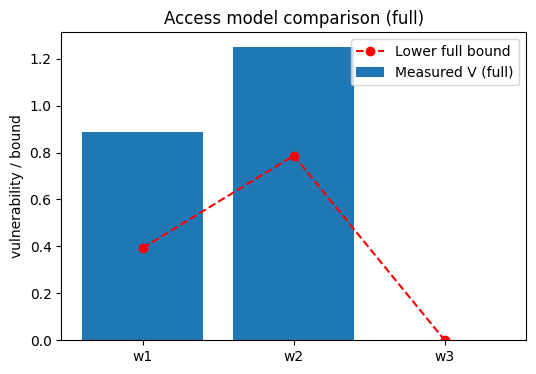

In [5]:
fam_access = mpm.family_vary_access(system, Q=np.zeros_like(G), access_models=['w1','w2','w3'], threat_model='full')
fam_access.data
_ = mpm.plot_access_model_comparison(fam_access.data, threat_model='full')


## 6) Family D: random conservative sanity checks
This block samples many small random systems, filters via conservative checks, and compares measured vulnerability against selected bounds.

**What it demonstrates:** distributional behavior of measured-vs-bound relationships, not a proof over all systems.

""


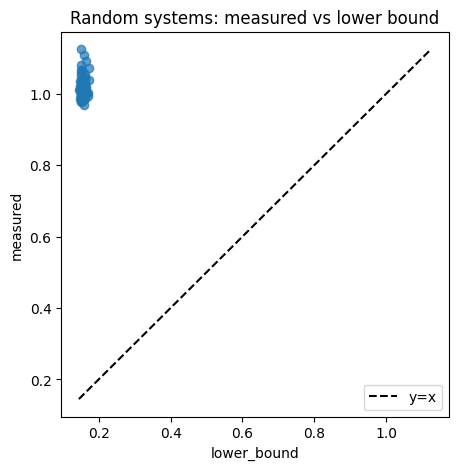

In [6]:
rand = mpm.random_bound_experiments(n_samples=80, n=3, seed=3, access_model='w2', threat_model='single_link')
rand.accepted.head()
if len(rand.accepted):
    _ = mpm.plot_bound_scatter(rand.accepted, bound_col='lower_bound', title='Random systems: measured vs lower bound')
rand.rejected.head()


## 7) Summarize and export markdown report
This final block compiles family summaries and exports a report file for reproducibility.

**Expected outcome:** summary table in-notebook and generated `reports/chapter2_demo_report.md`.

In [7]:
summary = mpm.summarize_experiment_results(fam_q, fam_a, fam_access)
mpm.export_report_markdown('reports/chapter2_demo_report.md', summary, headline='Chapter-2 demo report (notebook)')
summary


,family,n_rows,measured_min,measured_max,notes
0,vary_q,9,1.037667,1.148186,Threat model: single_link | Access model: w2
1,vary_alpha,11,1.000000,1.250081,Threat model: full | Access model: w2
2,vary_access,3,0.000000,1.250081,Threat model: full


## Takeaways and honesty notes
- This notebook provides numerical sanity checks on toy systems.
- Bound overlays are only meaningful under their stated threat/access assumptions.
- Results are empirical demonstrations, not theorem proofs.